<a href="https://colab.research.google.com/github/suryasridhar/regime-detection-and-optimization/blob/feature%2Fhmm/ETF_HMM_Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA
from scipy.optimize import minimize


In [160]:
start_date = '2002-09-01' 
end_date = '2024-01-01'
# We put ALL candidates in one big basket. 
# We don't tell the model which is "Growth" or "Defensive".

candidate_tickers = [
    'SPY',           # S&P 500 (Market)
    'QQQ',           # Nasdaq 100 (Growth)
    'XLK',           # Tech Sector (Growth)
    'XLE',           # Energy Sector (Inflation/Value)
    'XLV',           # Healthcare (Defensive)
    'XLP',           # Staples (Defensive)
    'TLT',           # 20+ Year Treasury (The Crisis Hedge) - Launched July 2002
    'IEF',           # 7-10 Year Treasury (Intermediate Safety) - Launched July 2002
    'LQD',           # Investment Grade Corp Bond (Credit Risk) - Launched July 2002
    'NEM',           # Gold Proxy (Newmont Mining) - Used because GLD didn't exist until 2004
]

In [161]:
universe_ohlcv = yf.download(candidate_tickers, start=start_date, end=end_date, group_by='column', auto_adjust=False)
universe_ohlcv = universe_ohlcv.dropna()

[*********************100%***********************]  10 of 10 completed


In [162]:
universe_ohlcv

Price       Adj Close                                                 \
Ticker            IEF         LQD        NEM         QQQ         SPY   
Date                                                                   
2002-09-03  43.373192   39.612736  19.437777   19.146944   57.446796   
2002-09-04  43.357937   39.758999  18.856049   19.223055   58.266705   
2002-09-05  43.530968   39.871445  19.538076   18.749456   57.772125   
2002-09-06  43.195061   39.601471  19.424402   19.324551   58.566040   
2002-09-09  43.134018   39.627731  19.845661   19.519056   58.995533   
...               ...         ...        ...         ...         ...   
2023-12-22  89.948761  101.517746  40.469662  404.226715  463.589142   
2023-12-26  90.004845  101.729843  40.325329  406.701355  465.546692   
2023-12-27  90.706177  102.679520  40.777557  407.529266  466.388428   
2023-12-28  90.360184  102.412163  40.123272  407.331207  466.564606   
2023-12-29  90.135757  102.034119  39.824989  405.568329  465.213867   

Price                                                                ...  \
Ticker            TLT        XLE         XLK        XLP         XLV  ...   
Date                                                                 ...   
2002-09-03  40.046879  11.675286   10.073519  11.715614   17.760471  ...   
2002-09-04  40.037815  11.648752   10.386915  11.810453   18.306738  ...   
2002-09-05  40.256126  11.669972   10.036209  11.804873   18.095055  ...   
2002-09-06  39.783039  11.861022   10.371993  11.804873   18.095055  ...   
2002-09-09  39.723934  11.845104   10.483920  12.039181   18.299900  ...   
...               ...        ...         ...        ...         ...  ...   
2023-12-22  91.241043  80.272049  189.848557  67.972267  131.168243  ...   
2023-12-26  91.500458  80.961609  190.639374  68.258583  131.459702  ...   
2023-12-27  93.121811  80.602676  190.629486  68.573540  132.013428  ...   
2023-12-28  92.445473  79.374687  190.856857  68.602165  132.353439  ...   
2023-12-29  91.611641  79.195229  190.273605  68.745323  132.489441  ...   

Price        Volume                                                    \
Ticker          IEF       LQD      NEM       QQQ        SPY       TLT   
Date                                                                    
2002-09-03   110700     49300  4460700  81828100   76586400    102100   
2002-09-04    77300   1690000  4369300  82717600   51099500     66300   
2002-09-05    57900    138300  5563300  91576600   67250900    648400   
2002-09-06    32200    224800  5734100  86008800   38622200    140000   
2002-09-09    88800     53600  6889700  72679500   33998400     83800   
...             ...       ...      ...       ...        ...       ...   
2023-12-22  4956400  11037100  9136800  34314000   67160400  29244200   
2023-12-26  3342500   5816000  4979200  22722500   55387000  24019700   
2023-12-27  7362400  13646400  7687800  31980500   68000300  45082800   
2023-12-28  4858500  14288800  6259400  27029200   77158100  36213000   
2023-12-29  7820500  17956700  6986200  42662100  122283100  41616200   

Price                                             
Ticker           XLE      XLK       XLP      XLV  
Date                                              
2002-09-03     88900  1459900     75000    55000  
2002-09-04    624500   919200     51700    87400  
2002-09-05    258300   392900     33500    31900  
2002-09-06    210500  2943900     65400    17700  
2002-09-09    103300   699200     37500    29300  
...              ...      ...       ...      ...  
2023-12-22  12518900  5107500   7831800  5355100  
2023-12-26  12991700  3103800   6915800  3688600  
2023-12-27  10119100  5882300   7566700  5444100  
2023-12-28  13099000  4807700   6466000  5800200  
2023-12-29  12172700  6095300  10412700  5590000  

[5369 rows x 60 columns]

In [163]:
vix = yf.download('^VIX', start=start_date, end=end_date, progress=False, auto_adjust=False, multi_level_index=False)['Adj Close']
vix

Date
2002-09-03    39.970001
2002-09-04    37.439999
2002-09-05    38.860001
2002-09-06    36.330002
2002-09-09    36.450001
                ...    
2023-12-22    13.030000
2023-12-26    12.990000
2023-12-27    12.430000
2023-12-28    12.470000
2023-12-29    12.450000
Name: Adj Close, Length: 5369, dtype: float64

In [164]:
adj_close = universe_ohlcv['Adj Close']
high = universe_ohlcv['High']
low = universe_ohlcv['Low']
close = universe_ohlcv['Close']
open_p = universe_ohlcv['Open']
volume = universe_ohlcv['Volume']

In [165]:
def calculate_yang_zhang_vol(open_df, high_df, low_df, close_df, window=14):
    """
    Vectorized Yang-Zhang Volatility.
    Captures Overnight Risk + Open-to-Close Risk efficiently.
    """
    # 1. Overnight Volatility (Close to Open)
    # Shift Close to get previous day's close
    log_oc = np.log(open_df / close_df.shift(1))
    # Rolling Variance of overnight jumps
    vo = log_oc.rolling(window=window).var()
    
    # 2. Open-to-Close Volatility
    log_co = np.log(close_df / open_df)
    vc = log_co.rolling(window=window).var()
    
    # 3. Rogers-Satchell Volatility (Intraday Trend-Agnostic)
    # RS = mean( log(H/C)*log(H/O) + log(L/C)*log(L/O) )
    log_hc = np.log(high_df / close_df)
    log_ho = np.log(high_df / open_df)
    log_lc = np.log(low_df / close_df)
    log_lo = np.log(low_df / open_df)
    
    rs_term = (log_hc * log_ho) + (log_lc * log_lo)
    vrs = rs_term.rolling(window=window).mean()
    
    # 4. Combine (Standard weights for YZ)
    k = 0.34 / (1.34 + (window + 1) / (window - 1))
    
    # Yang-Zhang Variance
    yz_var = vo + k * vc + (1 - k) * vrs
    
    # Annualize
    return np.sqrt(yz_var) * np.sqrt(252)

In [166]:
print("Calculating Yang-Zhang Volatility (Overnight Gap Aware)...")
# We use YZ Volatility as our primary "Risk" input now
feat_vol = calculate_yang_zhang_vol(open_p, high, low, close, window=14)

Calculating Yang-Zhang Volatility (Overnight Gap Aware)...


In [167]:
print("Calculating Rolling Skewness & Kurtosis (Tail Risk)...")
returns = adj_close.pct_change()

# Rolling Skew (63-day / Quarterly window is standard to reduce noise)
# Negative Skew = "Crash Risk" (Small wins, big losses)
feat_skew = returns.rolling(window=63).skew()

# Rolling Kurtosis (Fat Tails)
# High Kurtosis = "Fragile Market" (Frequent 3-sigma events)
feat_kurt = returns.rolling(window=63).kurt()

Calculating Rolling Skewness & Kurtosis (Tail Risk)...


In [168]:
# --- RSI (14-Day) ---
delta = adj_close.diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
feat_rsi = 100 - (100 / (1 + rs))

In [169]:
print("Calculating Momentum (14-Day Returns)...")
feat_mom = adj_close.pct_change(14)

Calculating Momentum (14-Day Returns)...


In [170]:
typical_price = (high + low + close) / 3
money_flow = typical_price * volume
tp_diff = typical_price.diff()
pos_flow = (money_flow * (tp_diff > 0).astype(int)).rolling(14).sum()
neg_flow = (money_flow * (tp_diff < 0).astype(int)).rolling(14).sum()
mfi_ratio = pos_flow / neg_flow
feat_mfi = 100 - (100 / (1 + mfi_ratio))

In [171]:
features = pd.DataFrame(index=adj_close.index)

In [172]:
print("Constructing High-Dimensional Feature Matrix...")
df = pd.concat([
    feat_vol.add_suffix('_YZ_Vol'),
    feat_skew.add_suffix('_Skew'),
    feat_kurt.add_suffix('_Kurt'),
    feat_mom.add_suffix('_Mom'), # Added Momentum
    feat_rsi.add_suffix('_RSI'),
    feat_mfi.add_suffix('_MFI')
], axis=1)


Constructing High-Dimensional Feature Matrix...


In [173]:
df = df.dropna()
df

Ticker,IEF_YZ_Vol,LQD_YZ_Vol,NEM_YZ_Vol,QQQ_YZ_Vol,SPY_YZ_Vol,TLT_YZ_Vol,XLE_YZ_Vol,XLK_YZ_Vol,XLP_YZ_Vol,XLV_YZ_Vol,...,IEF_MFI,LQD_MFI,NEM_MFI,QQQ_MFI,SPY_MFI,TLT_MFI,XLE_MFI,XLK_MFI,XLP_MFI,XLV_MFI
Date,,,,,,,,,,,,,,,,,,,,,
2002-12-02,0.090562,0.088241,0.462555,0.376274,0.214882,0.127344,0.202728,0.377478,0.190291,0.185377,...,9.380073,25.080414,28.821286,82.012675,68.463985,16.273236,70.814399,86.995138,39.831979,17.993979
2002-12-03,0.092859,0.088162,0.413424,0.374356,0.215447,0.130117,0.203723,0.381091,0.175246,0.196602,...,11.812610,60.029953,41.105145,74.969410,61.919616,22.936932,75.627698,74.930493,47.191419,17.347102
2002-12-04,0.096094,0.084618,0.408400,0.372651,0.214126,0.132263,0.183831,0.397385,0.172764,0.184409,...,23.172738,53.472613,51.018603,63.966404,61.617434,27.549589,70.778042,67.466749,47.196955,21.232398
2002-12-05,0.093195,0.079016,0.397293,0.368434,0.210130,0.129101,0.179360,0.390043,0.165157,0.181553,...,34.095933,56.269823,53.043344,56.598229,55.292629,34.123029,65.894177,62.404187,40.091737,21.962561
2002-12-06,0.100664,0.086764,0.442213,0.378538,0.218570,0.140493,0.187939,0.394006,0.167109,0.190618,...,42.621596,58.053839,57.533776,50.073981,47.287760,44.744745,70.564992,58.216100,40.700488,19.709592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.066007,0.078139,0.322355,0.125192,0.098429,0.141992,0.169892,0.127645,0.108790,0.106360,...,67.464738,72.026577,42.919844,91.584243,67.048377,64.887425,55.184880,82.145977,45.173235,65.278639
2023-12-26,0.063138,0.075268,0.315089,0.119427,0.096334,0.133554,0.169662,0.123748,0.108166,0.104634,...,61.117970,69.402599,45.123130,91.342439,72.658286,62.457617,61.036702,81.801300,50.714207,71.025618
2023-12-27,0.064917,0.077278,0.312857,0.113497,0.093078,0.138445,0.160191,0.117450,0.106646,0.104287,...,59.537470,68.479822,49.776425,91.235389,78.579992,61.659866,65.804009,76.047484,56.542211,70.840570


In [174]:
print("Applying Rolling Normalization (252-Day Window)...")

rolling_mean = df.rolling(window=252).mean()
rolling_std = df.rolling(window=252).std()
epsilon = 1e-8

normalized_df = (df - rolling_mean) / (rolling_std + epsilon)
normalized_df = normalized_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Applying 21-Day EMA Smoothing to Features (Anti-Chop)...")
normalized_df = normalized_df.ewm(span=21).mean()

print(f"Normalized & Smoothed Matrix Shape: {normalized_df.shape}")

Applying Rolling Normalization (252-Day Window)...
Applying 21-Day EMA Smoothing to Features (Anti-Chop)...
Normalized & Smoothed Matrix Shape: (5055, 60)


In [175]:
X_values = normalized_df.values
dates = normalized_df.index
returns_universe = np.log(adj_close / adj_close.shift(1)).reindex(dates)



In [186]:
dates

DatetimeIndex(['2003-12-01', '2003-12-02', '2003-12-03', '2003-12-04',
               '2003-12-05', '2003-12-08', '2003-12-09', '2003-12-10',
               '2003-12-11', '2003-12-12',
               ...
               '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
               '2023-12-28', '2023-12-29'],
              dtype='datetime64[ns]', name='Date', length=5055, freq=None)

In [177]:
# THE CUT-OFF POINT
# We use the first ~4 years (2006-2010) as "Burn-In" to initialize the model.
# We do NOT trade during this period.
initial_train_window = 1000
rebalance_step = 63 

# Print the Hard Line in the Sand
burn_in_end_date = dates[initial_train_window]
burn_in_end_date

Timestamp('2007-11-20 00:00:00')

In [178]:
print(f"1. In-Sample 'Burn-In' Period: {dates[0].date()} to {burn_in_end_date.date()}")

1. In-Sample 'Burn-In' Period: 2003-12-01 to 2007-11-20


In [187]:
def get_optimized_weights(returns_df, objective='sharpe'):
   
    num_assets = len(returns_df.columns)
    if num_assets == 0: return []
    if num_assets == 1: return np.array([1.0]) 
    
    mean_rets = returns_df.mean() * 252
    cov_matrix = returns_df.cov() * 252
    
    #Only longs
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array([1/num_assets] * num_assets)
    
    def min_variance_func(weights):
        return np.dot(weights, np.dot(cov_matrix, weights.T))
        
    def sharpe_func(weights):
        # Positive Sharpe Ratio (Maximize this)
        port_ret = np.sum(mean_rets * weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return (port_ret / port_vol) if port_vol > 0 else 0

    if objective == 'min_var':
        result = minimize(min_variance_func, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    else: # Mean-Variance (Max Sharpe)
        result = minimize(lambda w: -sharpe_func(w), initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
        
    return result.x

In [ ]:
vol_cols = [i for i, col in enumerate(normalized_df.columns) if '_YZ_Vol' in col]

initial_train_window = 1000 
rebalance_step = 63 

portfolio_log_returns = []
benchmark_log_returns = []
regime_history = []

# CONFIGURATION
n_pca_components = 4 
n_hmm_states = 2
pca = PCA(n_components=n_pca_components) 


SWITCH_THRESHOLD = 0.9
current_regime = 0 # Start assuming Low Vol (Green)

print(f"--- Starting Walk-Forward Loop (Hysteresis={SWITCH_THRESHOLD}) ---")

for t in range(initial_train_window, len(X_values), rebalance_step):
    
    # 1. TRAIN
    X_train = X_values[:t]
    train_returns = returns_universe.iloc[:t] # Historical Returns
    
    X_train_pca = pca.fit_transform(X_train)
    hmm = GaussianHMM(n_components=n_hmm_states, covariance_type="full", n_iter=100, random_state=42)
    hmm.fit(X_train_pca)
    train_states_raw = hmm.predict(X_train_pca)
    
    # State Alignment (0=LowVol, 1=HighVol)
    state_vol_means = []
    for s in range(n_hmm_states):
        avg_vol = X_train[train_states_raw == s][:, vol_cols].mean()
        state_vol_means.append((s, avg_vol))
    state_vol_means.sort(key=lambda x: x[1])
    map_dict = { old_id: new_id for new_id, (old_id, vol) in enumerate(state_vol_means) }
    train_states = np.array([map_dict[s] for s in train_states_raw])
    
    # 2. ASSET SELECTION & OPTIMIZATION (THE NEW PART)
    # Instead of just storing a list of tickers, we store a DICTIONARY of {ticker: weight}
    state_playbook = {}
    
    for state in range(n_hmm_states):
        mask = (train_states == state)
        
        if np.sum(mask) > 20:
            # Get returns SPECIFIC to this regime
            regime_returns = train_returns[mask]
            avg_daily_rets = regime_returns.mean()
            
            # Filter: Positive Expectancy
            valid_assets = avg_daily_rets[avg_daily_rets > 0].index.tolist()
            
            if len(valid_assets) == 0:
                # Fallback
                state_playbook[state] = {'IEF': 1.0}
            else:
                # --- OPTIMIZATION LOGIC ---
                # Sub-select returns for valid assets
                opt_returns = regime_returns[valid_assets]
                
                if state == 0:
                    # STATE 0 (Growth): Maximize Sharpe (Mean-Variance)
                    # We want to ride the trend but efficiently.
                    weights = get_optimized_weights(opt_returns, objective='sharpe')
                else:
                    # STATE 1 (Crisis): Minimize Variance
                    # We want to survive. Ignore returns, just kill volatility.
                    weights = get_optimized_weights(opt_returns, objective='min_var')
                
                # Store result
                state_playbook[state] = dict(zip(valid_assets, weights))
                
        else:
            # Not enough data history for this state yet
            state_playbook[state] = {'SPY': 1.0}
            
    # 3. PREDICT
    end_idx = min(t + rebalance_step, len(X_values))
    X_test = X_values[t:end_idx]
    test_returns_slice = returns_universe.iloc[t:end_idx]
    
    X_test_pca = pca.transform(X_test)
    raw_probs = hmm.predict_proba(X_test_pca)
    
    aligned_probs = np.zeros_like(raw_probs)
    for old_id, new_id in map_dict.items():
        aligned_probs[:, new_id] = raw_probs[:, old_id]
    
    probs_df = pd.DataFrame(aligned_probs)
    smoothed_probs = probs_df.ewm(span=5).mean().values
    
    smoothed_states = []
    for i in range(len(smoothed_probs)):
        prob_red = smoothed_probs[i, 1]
        if current_regime == 0: 
            if prob_red > SWITCH_THRESHOLD: current_regime = 1
        else: 
            if prob_red < (1.0 - SWITCH_THRESHOLD): current_regime = 0
        smoothed_states.append(current_regime)
    
    regime_history.extend(smoothed_states)
    
    # 4. EXECUTION (WEIGHTED)
    for i, daily_state in enumerate(smoothed_states):
        # Get the weight dict for this state
        weights_dict = state_playbook[daily_state]
        
        # Calculate weighted return
        daily_ret = 0.0
        for ticker, weight in weights_dict.items():
            daily_ret += test_returns_slice.iloc[i][ticker] * weight
            
        portfolio_log_returns.append(daily_ret)
        benchmark_log_returns.append(test_returns_slice.iloc[i]['SPY'])

    if t % 252 == 0:
        print(f"Simulating: {dates[t].date()}...")
    
    # 1. TRAIN
    X_train = X_values[:t]
    train_returns = returns_universe.iloc[:t]
    
    # PCA
    X_train_pca = pca.fit_transform(X_train)
    
    # HMM
    hmm = GaussianHMM(n_components=n_hmm_states, covariance_type="full", n_iter=100, random_state=42)
    hmm.fit(X_train_pca)
    train_states_raw = hmm.predict(X_train_pca)
    
    # --- STATE ALIGNMENT ---
    # Identify which raw state is "Low Volatility" (State 0)
    state_vol_means = []
    for s in range(n_hmm_states):
        avg_vol = X_train[train_states_raw == s][:, vol_cols].mean()
        state_vol_means.append((s, avg_vol))
        
    # Sort: Lowest Vol -> State 0
    state_vol_means.sort(key=lambda x: x[1])
    map_dict = { old_id: new_id for new_id, (old_id, vol) in enumerate(state_vol_means) }
    
    # Remap training states for asset selection
    train_states = np.array([map_dict[s] for s in train_states_raw])
    
    # 2. ASSET SELECTION
    state_playbook = {}
    for state in range(n_hmm_states):
        mask = (train_states == state)
        if np.sum(mask) > 10:
            avg_daily_rets = train_returns[mask].mean()
            positive_assets = avg_daily_rets[avg_daily_rets > 0].index.tolist()
            if len(positive_assets) > 0:
                state_playbook[state] = positive_assets
            else:
                state_playbook[state] = ['IEF'] 
        else:
            state_playbook[state] = ['SPY']
            
    # 3. PREDICT WITH HYSTERESIS
    end_idx = min(t + rebalance_step, len(X_values))
    X_test = X_values[t:end_idx]
    test_returns_slice = returns_universe.iloc[t:end_idx]
    
    # Transform Test Data
    X_test_pca = pca.transform(X_test)
    
    # Get PROBABILITIES instead of hard predictions
    raw_probs = hmm.predict_proba(X_test_pca)
    
    # Align Probabilities to match our Sorted States (0=Green, 1=Red)
    # If map_dict says {0:1, 1:0}, we must swap the prob columns
    # We create a new aligned_probs matrix
    aligned_probs = np.zeros_like(raw_probs)
    for old_id, new_id in map_dict.items():
        aligned_probs[:, new_id] = raw_probs[:, old_id]
    
    # Apply Hysteresis Logic
    smoothed_states = []
    for i in range(len(aligned_probs)):
        # Probability of High Vol (State 1)
        prob_red = aligned_probs[i, 1]
        
        if current_regime == 0: # Currently Green
            # Only switch to Red if VERY sure (Prob > 0.70)
            if prob_red > SWITCH_THRESHOLD:
                current_regime = 1
        else: # Currently Red
            # Only switch back to Green if probability of Red drops significantly (e.g. < 0.30)
            # equivalent to Prob Green > 0.70
            if prob_red < (1.0 - SWITCH_THRESHOLD):
                current_regime = 0
        
        smoothed_states.append(current_regime)
    
    regime_history.extend(smoothed_states)
    
    # 4. EXECUTION
    for i, daily_state in enumerate(smoothed_states):
        assets_to_hold = state_playbook[daily_state]
        daily_asset_rets = test_returns_slice.iloc[i][assets_to_hold].mean()
        
        portfolio_log_returns.append(daily_asset_rets)
        benchmark_log_returns.append(test_returns_slice.iloc[i]['SPY'])

    if t % 252 == 0:
        print(f"Simulating: {dates[t].date()}...")



--- Starting Walk-Forward Loop (Hysteresis=0.9) ---


In [185]:
len(result_dates)

4055

In [181]:
result_dates = dates[initial_train_window:initial_train_window+len(portfolio_log_returns)]
results = pd.DataFrame({'Strategy': np.exp(np.cumsum(portfolio_log_returns)), 
                        'Benchmark': np.exp(np.cumsum(benchmark_log_returns)), 
                        'Regime': regime_history}, index=result_dates)


ValueError: Length of values (8110) does not match length of index (4055)

In [ ]:
results

,Strategy,Benchmark,Regime
Date,,,
2007-11-20,1.010058,1.006122,0
2007-11-21,1.001414,0.985531,1
2007-11-23,1.010857,1.002574,1
2007-11-26,1.005409,0.980453,1
2007-11-27,1.007418,0.991722,1
...,...,...,...
2023-12-22,2.988642,4.514029,0
2023-12-26,3.000287,4.533090,0
2023-12-27,3.014579,4.541286,0


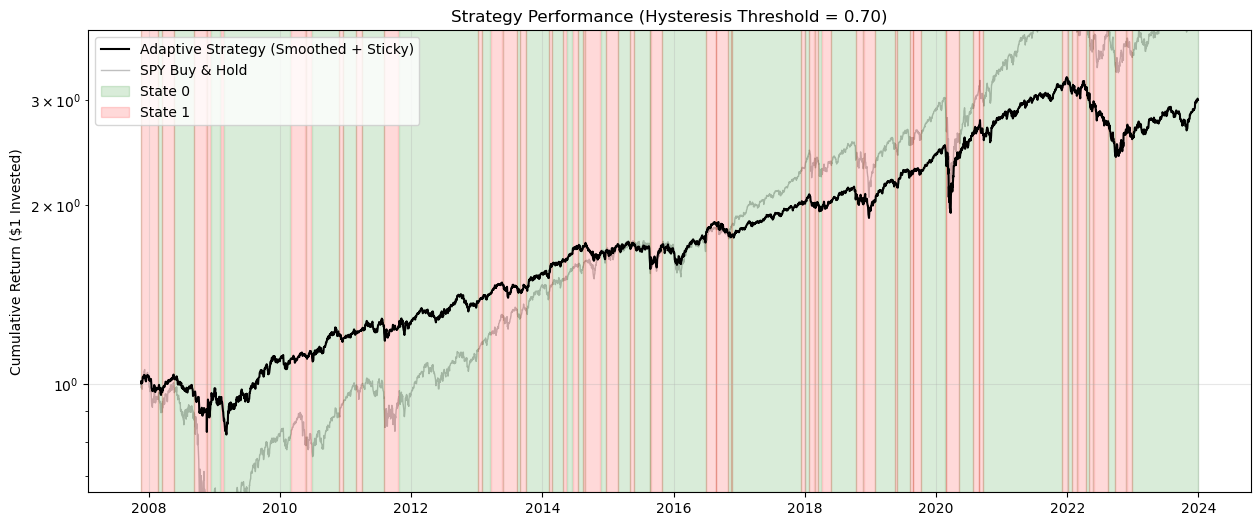

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(results['Strategy'], label='Adaptive Strategy (Smoothed + Sticky)', color='black', linewidth=1.5, zorder=2)
ax.plot(results['Benchmark'], label='SPY Buy & Hold', color='gray', alpha=0.5, linewidth=1, zorder=1)

state_colors = {0: 'green', 1: 'red'}
y_min, y_max = ax.get_ylim()
for state in range(n_hmm_states):
    mask = (results['Regime'] == state)
    ax.fill_between(results.index, 0, 100000, where=mask, 
                    color=state_colors.get(state, 'blue'), alpha=0.15, 
                    transform=ax.get_xaxis_transform(), label=f'State {state}')

ax.set_yscale('log')
ax.set_title("Strategy Performance (Hysteresis Threshold = 0.70)")
ax.set_ylabel("Cumulative Return ($1 Invested)")
ax.set_ylim(results['Strategy'].min() * 0.8, results['Strategy'].max() * 1.2)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

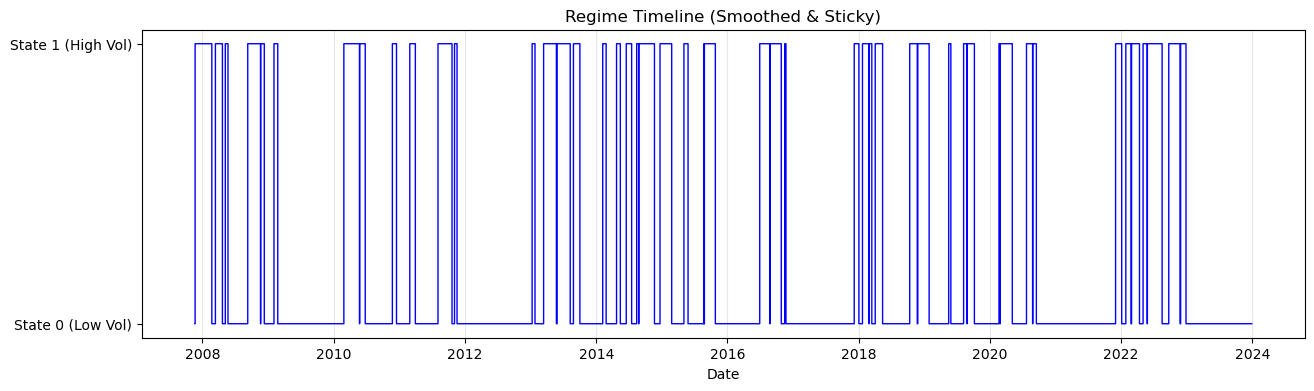

In [ ]:
# PLOT 2: REGIME TIMELINE (DE-BARCODED)
plt.figure(figsize=(15, 4))
plt.plot(results.index, results['Regime'], drawstyle='steps-post', color='blue', linewidth=1)
plt.yticks([0, 1], ['State 0 (Low Vol)', 'State 1 (High Vol)'])
plt.title("Regime Timeline (Smoothed & Sticky)")
plt.xlabel("Date")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [ ]:
%pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt
latest = data_with_pca_reduced
latest[latest['regime']==0]


,0,1,2,3,4,5,6,7,8,9,10,vix_scaled,regime
Date,,,,,,,,,,,,,
2020-02-06,-1.991108,0.499016,-0.034660,0.633759,-0.972694,-0.094306,0.277363,-0.155686,-0.929999,-0.769148,-0.594497,-0.795603,0
2020-02-10,-2.106127,1.222574,-0.216938,0.842205,-0.686116,-0.679720,0.251358,0.028186,-0.743426,-0.822657,-0.593535,-0.785923,0
2020-02-13,-2.058759,0.757500,0.235958,-0.131141,-1.362493,-1.226327,-0.065985,0.301268,0.251033,-0.963654,-0.344239,-0.893616,0
2020-02-19,-1.925917,1.733245,0.615833,0.242412,-2.080629,-0.889765,0.874312,-0.616163,0.261987,-0.974290,-0.402385,-0.865785,0
2020-03-06,-2.085589,-3.973448,-1.321277,0.113381,1.997038,1.169280,2.834010,0.279116,-0.900798,-0.386325,-0.846131,2.469052,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-04,4.482869,1.093308,0.163928,0.857558,-0.771980,-0.915768,-0.691987,1.218893,-1.523840,2.026500,0.722933,-0.978317,0
2024-12-19,6.431482,-4.127945,5.874141,1.415999,-3.910733,-1.301456,1.949408,-3.072217,1.438498,-1.489729,0.429248,0.309152,0
2024-12-23,6.247250,-1.337854,3.005229,2.534857,-4.267530,-1.299209,2.210068,-1.732724,0.472708,-1.113403,1.180771,-0.575378,0


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# ==========================================
# CELL 1: DEFINE UNIVERSE & FETCH DATA
# ==========================================

# 1. Define Tickers directly
benchmark = 'SPY'
growth_etfs = ['QQQ', 'XLK', 'XLY'] 
defensive_etfs = ['XLP', 'XLU'] 
inflation_etfs = ['GLD', 'DBC'] 
crisis_etfs = ['TLT']

# Macro Tickers
vix_ticker = '^VIX'       # Volatility Index
ten_year_yield = '^TNX'   # 10Y Treasury Yield
three_month_yield = '^IRX' # 3M Treasury Bill
junk_bond = 'HYG'         # High Yield Corp Bond
gov_bond = 'TLT'          # Safe Haven Bond

start_date = '2006-02-01' 
end_date = '2024-01-01'

print("--- 1. Fetching Tradable Assets ---")
tickers = [benchmark] + growth_etfs + defensive_etfs + inflation_etfs + crisis_etfs
prices = yf.download(tickers, start=start_date, end=end_date, progress=False)['Adj Close']

print("--- 2. Fetching Macro Indicators ---")
macro_data = pd.DataFrame()
macro_data['VIX'] = yf.download(vix_ticker, start=start_date, end=end_date, progress=False)['Adj Close']
macro_data['US10Y'] = yf.download(ten_year_yield, start=start_date, end=end_date, progress=False)['Adj Close']
macro_data['US3M'] = yf.download(three_month_yield, start=start_date, end=end_date, progress=False)['Adj Close']
macro_data['HYG'] = yf.download(junk_bond, start=start_date, end=end_date, progress=False)['Adj Close']
macro_data['TLT'] = yf.download(gov_bond, start=start_date, end=end_date, progress=False)['Adj Close']

print("Data fetch complete.")

# ==========================================
# CELL 2: KALMAN FILTER IMPLEMENTATION
# ==========================================
class KalmanFilterRegression:
    def __init__(self, delta=1e-4, R=1e-3):
        self.delta = delta 
        self.R = R
        
    def fit(self, x, y):
        n = len(y)
        beta = np.zeros(n)
        P = np.zeros(n)
        beta[0] = 0
        P[0] = 1.0
        
        for t in range(1, n):
            beta_pred = beta[t-1]
            P_pred = P[t-1] + self.delta
            y_pred = beta_pred * x[t]
            residual = y[t] - y_pred
            variance = P_pred * x[t]**2 + self.R
            K = P_pred * x[t] / variance
            beta[t] = beta_pred + K * residual
            P[t] = P_pred - K * x[t] * P_pred
            
        return beta

# ==========================================
# CELL 3: FEATURE ENGINEERING
# ==========================================

raw_returns = np.log(prices / prices.shift(1)).dropna()

# Smoothed Returns (Log Return of 7-Day MA) - Feature 1
ma_7 = prices.rolling(window=7).mean()
smoothed_returns = np.log(ma_7 / ma_7.shift(1)).dropna()

aligned_macro = macro_data.reindex(raw_returns.index).ffill()
features = pd.DataFrame(index=raw_returns.index)

# Feature 2: Volatility
features['Vol_Realized'] = raw_returns['SPY'].rolling(window=21).std() * np.sqrt(252)

# Feature 3: Variance Risk Premium
features['Var_Risk_Premium'] = (aligned_macro['VIX'] / 100) - features['Vol_Realized']

# Feature 4: Yield Curve
features['Yield_Curve'] = aligned_macro['US10Y'] - aligned_macro['US3M']

# Feature 5: Credit Stress
features['Credit_Stress'] = aligned_macro['TLT'] / aligned_macro['HYG']

# Feature 6: Trend Efficiency
direction = prices['SPY'].diff(21).abs()
volatility = prices['SPY'].diff(1).abs().rolling(window=21).sum()
features['Trend_Efficiency'] = direction / volatility

# Feature 7: Kalman Beta (The Structural Key)
kf = KalmanFilterRegression(delta=1e-4, R=1e-3)
features['Kalman_Beta_TLT_SPY'] = kf.fit(raw_returns['SPY'].values, raw_returns['TLT'].values)

# Combine
final_dataset = pd.concat([smoothed_returns['SPY'].rename('Signal_Return'), features], axis=1).dropna()
print("Feature Engineering Complete.")

# ==========================================
# CELL 4: HMM MODELING (UNSUPERVISED)
# ==========================================

# 1. Select Observations for the HMM
# We choose features that describe "Structure" rather than just "Price"
obs_cols = [
    'Vol_Realized',         # Risk Level
    'Kalman_Beta_TLT_SPY',  # Correlation Structure (Inflation vs Normal)
    'Yield_Curve',          # Macro Cycle
    'Trend_Efficiency'      # Market Quality
]
X_train = final_dataset[obs_cols].values

# 2. Standardization (CRITICAL)
# HMMs are distance-based; features must be on same scale (Z-Scores)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 3. Fit Gaussian HMM
print("--- Fitting HMM ---")
# n_components=3 (State 0, State 1, State 2)
# covariance_type='full' allows for complex relationships between features in each state
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(X_scaled)

# 4. Predict States
hidden_states = hmm_model.predict(X_scaled)
final_dataset['HMM_State'] = hidden_states

# ==========================================
# CELL 5: INTERPRETING THE BLACK BOX
# ==========================================
print("\n--- Regime Analysis (What did the HMM find?) ---")

# We group by the discovered state to see the average feature values
regime_stats = final_dataset.groupby('HMM_State')[obs_cols + ['Signal_Return']].mean()
print(regime_stats)

# Logic to Auto-Label the States based on the results
# We look for the state with the Highest Volatility (Crisis)
vol_col = 'Vol_Realized'
crisis_state = regime_stats[vol_col].idxmax()

# We look for the state with Lowest Volatility (Bull/Growth)
growth_state = regime_stats[vol_col].idxmin()

# The remaining state is likely "Transition" or "Stagflation"
all_states = set([0, 1, 2])
remaining_state = list(all_states - {crisis_state, growth_state})[0]

state_map = {
    growth_state: 'Growth (Low Vol)',
    crisis_state: 'Crisis (High Vol)',
    remaining_state: 'Neutral/Transition'
}

print(f"\nAuto-Labelling based on Volatility:")
print(f"State {growth_state} -> Growth")
print(f"State {crisis_state} -> Crisis")
print(f"State {remaining_state} -> Neutral/Transition")

# ==========================================
# CELL 6: VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 10))
colors = ['green', 'red', 'orange']

# Plot SPY Price colored by Regime
# We have to re-index the prices to match the final dataset (dropped NaNs)
spy_aligned = prices['SPY'].reindex(final_dataset.index)

for i, state in enumerate([growth_state, crisis_state, remaining_state]):
    mask = (final_dataset['HMM_State'] == state)
    plt.plot(spy_aligned[mask].index, spy_aligned[mask], 
             marker='.', linestyle='none', markersize=2, 
             label=f'Regime {state}: {state_map[state]}', color=colors[i], alpha=0.6)

plt.plot(spy_aligned.index, spy_aligned, color='gray', alpha=0.1) # Background trace
plt.title(f"SPY Price Colored by Unsupervised HMM Regimes (3 States)")
plt.legend()
plt.show()

# Plot the "Killer Feature" Breakdown
plt.figure(figsize=(10, 6))
sns.violinplot(x='HMM_State', y='Kalman_Beta_TLT_SPY', data=final_dataset, palette=colors)
plt.title("Distribution of Stock-Bond Correlations by Regime")
plt.grid(True, alpha=0.3)
plt.show()

--- 1. Fetching Tradable Assets ---


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_32546/529467949.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date, progress=False)['Adj Close']


KeyError: 'Adj Close'